# Rollout Cases for `HexnerModGame` (Amortized Alpha)

This notebook:
- Loads a trained amortized checkpoint from `train_hexner_mod_amortized.py`.
- Evaluates a fixed set of `(prior, x0)` cases.
- Generates deterministic rollout trajectories per true type.
- Plots trajectory maps + belief trajectories.

For the mod game there is no analytical ground-truth baseline, so this notebook focuses on policy behavior and realized costs.


In [1]:
import os
import sys
from typing import Dict, List

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add repo root to path (works from notebooks/ or repo root)
CWD = os.getcwd()
if os.path.basename(CWD) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(CWD, ".."))
else:
    REPO_ROOT = CWD
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("Repo root:", REPO_ROOT)


Repo root: /Users/mghimire/Research/MPC_2p0s1


In [2]:
from MPC_2p0s1.config.base_config import GameConfig, project_relative
from MPC_2p0s1.core.action_spaces import BoxActionSpace
from MPC_2p0s1.games.hexner_mod_game import HexnerModGame, HexnerModParams
from MPC_2p0s1.outer_opt.amortized_alpha import (
    AmortizedAlphaConfig,
    AmortizedAlphaParam,
    primal_objective_from_alpha,
)
from MPC_2p0s1.tree.indexing import FullIaryTreeIndexer
from MPC_2p0s1.tree.rollout import rollout_trajectory
from MPC_2p0s1.viz.visualization_mod import (
    plot_hexner_mod_context,
    plot_hexner_mod_trajectory,
)


In [3]:
device = torch.device("cpu")
CHECKPOINT_PATH = project_relative("runs/hexner_mod_amortized_long/latest.pt")

print(f"Checkpoint: {CHECKPOINT_PATH}")


def _rebuild_game_config(meta_dict: Dict) -> GameConfig:
    cfg = GameConfig()
    for k, v in meta_dict.items():
        setattr(cfg, k, v)

    if not hasattr(cfg, "dx"):
        cfg.dx = cfg.dx1 + cfg.dx2
    if not hasattr(cfg, "tau") and hasattr(cfg, "T") and hasattr(cfg, "K"):
        cfg.tau = cfg.T / cfg.K

    cfg.device = str(device)
    cfg.device_resolved = device
    if not hasattr(cfg, "dtype"):
        cfg.dtype = torch.float32

    return cfg


def _parse_tuple_floats(csv_text: str):
    return tuple(float(v.strip()) for v in str(csv_text).split(",") if v.strip())


def _parse_tuple_ints(csv_text: str):
    return tuple(int(v.strip()) for v in str(csv_text).split(",") if v.strip())


Checkpoint: /Users/mghimire/Research/MPC_2p0s1/runs/hexner_mod_amortized_long/latest.pt


In [4]:
payload = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
meta = payload.get("meta", {})

if "model_state_dict" not in payload:
    raise RuntimeError(
        "Checkpoint does not contain 'model_state_dict'. "
        "Please use an amortized checkpoint from train_hexner_mod_amortized.py."
    )

game_cfg = _rebuild_game_config(meta.get("game_config", {}))
args_ckpt = meta.get("args", {})

indexer = FullIaryTreeIndexer(I=game_cfg.I, K=game_cfg.K)

hidden_dims = _parse_tuple_ints(args_ckpt.get("hidden_dims", "256,256"))
amort_cfg = AmortizedAlphaConfig(
    hidden_dims=hidden_dims,
    activation=str(args_ckpt.get("activation", "silu")),
    dropout=float(args_ckpt.get("dropout", 0.0)),
)

model = AmortizedAlphaParam(
    indexer=indexer,
    dx=game_cfg.dx,
    I=game_cfg.I,
    cfg=amort_cfg,
    dtype=game_cfg.dtype,
    device=device,
)
model.load_state_dict(payload["model_state_dict"])
model.eval()

hexner_mod_params = HexnerModParams(
    theta_values=_parse_tuple_floats(args_ckpt.get("theta_values", "-1.0,1.0")),
    target_z=None,
    R1_scale=float(args_ckpt.get("R1_scale", 1.0)),
    R2_scale=float(args_ckpt.get("R2_scale", 0.4)),
    K1_scale=float(args_ckpt.get("K1_scale", 1.0)),
    K2_scale=float(args_ckpt.get("K2_scale", 1.0)),
)

game = HexnerModGame(cfg=game_cfg, params=hexner_mod_params, prior=None)
action_space = BoxActionSpace.from_config(game_cfg)
USE_ACTION_CLIP = False  # set True only if you explicitly want clipped rollout evaluation
PROJECT_ALPHA_ONEHOT = False  # True only for deterministic-path debugging
USE_HANDCRAFTED_CI_ALPHA = True  # CI baseline: no NN; fixed alpha + Riccati solve
ROLLOUT_SAMPLE_ACTIONS = False #(not PROJECT_ALPHA_ONEHOT)
ROLLOUT_NUM_TRIALS = 64 if ROLLOUT_SAMPLE_ACTIONS else 1
eval_action_space = action_space if USE_ACTION_CLIP else None

print(
    f"Loaded amortized checkpoint: step={meta.get('step', '?')}, "
    f"train_loss={meta.get('train_loss', '?')}, eval_loss={meta.get('eval_loss', '?')}"
)
print(f"Game: I={game_cfg.I}, K={game_cfg.K}, T={game_cfg.T}, dtype={game_cfg.dtype}")
print(f"Model hidden_dims={hidden_dims}, activation={amort_cfg.activation}, dropout={amort_cfg.dropout}")
print(f"Eval action clipping enabled: {USE_ACTION_CLIP}")
print(f"Project alpha to one-hot: {PROJECT_ALPHA_ONEHOT}")
print(f"Use handcrafted CI alpha: {USE_HANDCRAFTED_CI_ALPHA}")
print(f"Rollout sampling: {ROLLOUT_SAMPLE_ACTIONS}, trials/type={ROLLOUT_NUM_TRIALS}")


Loaded amortized checkpoint: step=4999, train_loss=0.09126466512680054, eval_loss=0.06202588975429535
Game: I=2, K=10, T=1.0, dtype=torch.float32
Model hidden_dims=(64,), activation=silu, dropout=0.0
Eval action clipping enabled: False
Project alpha to one-hot: False
Use handcrafted CI alpha: True
Rollout sampling: False, trials/type=1


In [5]:
dtype = game_cfg.dtype
base_x0 = game.default_initial_state().to(device=device, dtype=dtype)


def make_x0(
    p1x=-1.0, p1y=0.0, p1vx=0.0, p1vy=0.0,
    p2x=1.0, p2y=0.0, p2vx=0.0, p2vy=0.0,
):
    return torch.tensor(
        [p1x, p1y, p1vx, p1vy, p2x, p2y, p2vx, p2vy],
        device=device,
        dtype=dtype,
    )

x0_center = base_x0.clone()
# x0_center = make_x0(p1x=0, p1y=0, p2x=0, p2y=0)
x0_topright = make_x0(p1x=0.2, p1y=0.6, p2x=1.2, p2y=0.8)

scenarios: List[Dict] = [
    {
        "name": "S0 balanced_center",
        "prior": torch.tensor([0.5, 0.5], device=device, dtype=dtype),
        "x0": x0_center,
        "note": "neutral geometry",
    },
    # {
    #     "name": "S1 rare_type1_center",
    #     "prior": torch.tensor([0.9, 0.1], device=device, dtype=dtype),
    #     "x0": x0_center,
    #     "note": "type-1 is rare under prior",
    # },
    # {
    #     "name": "S2 rare_type1_topright",
    #     "prior": torch.tensor([0.9, 0.1], device=device, dtype=dtype),
    #     "x0": x0_topright,
    #     "note": "same prior, different state",
    # },
    {
        "name": "S3 common_type1_topright",
        "prior": torch.tensor([0.1, 0.9], device=device, dtype=dtype),
        "x0": x0_topright,
        "note": "prior flipped",
    },
]

print("Scenarios:")
for s in scenarios:
    print(f"  {s['name']}: prior={s['prior'].tolist()}, note={s['note']}")


Scenarios:
  S0 balanced_center: prior=[0.5, 0.5], note=neutral geometry
  S3 common_type1_topright: prior=[0.10000000149011612, 0.8999999761581421], note=prior flipped


In [6]:
def rollout_total_cost(game: HexnerModGame, rollout, type_index: int) -> float:
    u = rollout.u_traj
    v = rollout.v_traj
    R_i = game.R[type_index]
    S_i = game.S[type_index]

    tau = float(game.cfg.tau)
    run_u = 0.5 * tau * torch.einsum("kd,dd,kd->k", u, R_i, u)
    run_v = 0.5 * tau * torch.einsum("kd,dd,kd->k", v, S_i, v)
    running = (run_u - run_v).sum()
    terminal = game.terminal_cost_type(type_index, rollout.x_traj[-1])
    return float((running + terminal).detach().cpu().item())


def project_alpha_onehot(alpha: torch.Tensor) -> torch.Tensor:
    """Project mixed alpha onto deterministic prototypes (argmax per row)."""
    idx = torch.argmax(alpha, dim=-1, keepdim=True)
    out = torch.zeros_like(alpha)
    out.scatter_(-1, idx, 1.0)
    return out




def estimate_rollout_cost(
    *,
    alpha_eval: torch.Tensor,
    belief_tree_eval,
    riccati_eval,
    x0_eval: torch.Tensor,
    type_index: int,
    seed_offset: int,
):
    costs = []
    first_ro = None
    for trial in range(int(ROLLOUT_NUM_TRIALS)):
        gen = None
        if ROLLOUT_SAMPLE_ACTIONS:
            gen = torch.Generator(device=device)
            gen.manual_seed(int(game_cfg.seed) + int(seed_offset) + int(trial))

        ro = rollout_trajectory(
            game=game,
            indexer=indexer,
            belief_tree=belief_tree_eval,
            riccati_sol=riccati_eval,
            alpha=alpha_eval,
            x0=x0_eval,
            type_index=type_index,
            action_space=eval_action_space,
            sample_actions=ROLLOUT_SAMPLE_ACTIONS,
            generator=gen,
        )
        if first_ro is None:
            first_ro = ro
        costs.append(rollout_total_cost(game=game, rollout=ro, type_index=type_index))

    arr = np.asarray(costs, dtype=np.float64)
    mean = float(arr.mean())
    std = float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    return first_ro, mean, std




def build_handcrafted_complete_info_alpha(action_index: int = 0) -> torch.Tensor:
    """
    Build a fixed deterministic alpha for CI baseline (no NN).

    All types pick the same public action index; with one-hot prior this yields a
    complete-information baseline without amortization/generalization error.
    """
    if not (0 <= int(action_index) < game.I):
        raise ValueError(f"action_index must be in [0, {game.I}), got {action_index}")

    alpha_ci = torch.zeros(
        indexer.K,
        indexer.max_nodes_per_depth,
        game.I,
        game.I,
        device=device,
        dtype=game_cfg.dtype,
    )
    alpha_ci[..., int(action_index)] = 1.0
    return alpha_ci


def evaluate_scenario(prior: torch.Tensor, x0: torch.Tensor):
    with torch.no_grad():
        alpha_tree = model.single_alpha(x0=x0, p0=prior)
        if PROJECT_ALPHA_ONEHOT:
            alpha_tree = project_alpha_onehot(alpha_tree)

    loss, details = primal_objective_from_alpha(
        game=game,
        alpha=alpha_tree,
        indexer=indexer,
        x0=x0,
        p0=prior,
        action_space=eval_action_space,
        return_details=True,
    )

    belief_tree = details["belief_tree"]
    riccati_sol = details["riccati_solution"]

    out = {
        "root_loss": float(loss.detach().cpu().item()),
        "alpha": alpha_tree,
        "belief_tree": belief_tree,
        "riccati_sol": riccati_sol,
        "rollouts": {},
        "complete_info": {},
    }

    alpha_ci_handcrafted = None
    if USE_HANDCRAFTED_CI_ALPHA:
        alpha_ci_handcrafted = build_handcrafted_complete_info_alpha(action_index=0)

    for type_idx in range(game.I):
        # rollout under scenario prior (mean over trials if sampling enabled)
        ro, cost_policy, cost_policy_std = estimate_rollout_cost(
            alpha_eval=alpha_tree,
            belief_tree_eval=belief_tree,
            riccati_eval=riccati_sol,
            x0_eval=x0,
            type_index=type_idx,
            seed_offset=10000 + 1000 * int(type_idx),
        )

        # complete-information rollout with exact one-hot prior on true type
        prior_ci = torch.zeros_like(prior)
        prior_ci[type_idx] = 1.0

        if USE_HANDCRAFTED_CI_ALPHA:
            alpha_ci = alpha_ci_handcrafted
        else:
            with torch.no_grad():
                alpha_ci = model.single_alpha(x0=x0, p0=prior_ci)
                if PROJECT_ALPHA_ONEHOT:
                    alpha_ci = project_alpha_onehot(alpha_ci)

        loss_ci, details_ci = primal_objective_from_alpha(
            game=game,
            alpha=alpha_ci,
            indexer=indexer,
            x0=x0,
            p0=prior_ci,
            action_space=eval_action_space,
            return_details=True,
        )

        ro_ci, cost_ci, cost_ci_std = estimate_rollout_cost(
            alpha_eval=alpha_ci,
            belief_tree_eval=details_ci["belief_tree"],
            riccati_eval=details_ci["riccati_solution"],
            x0_eval=x0,
            type_index=type_idx,
            seed_offset=20000 + 1000 * int(type_idx),
        )

        out["rollouts"][type_idx] = {
            "rollout": ro,
            "cost": cost_policy,
            "cost_std": float(cost_policy_std),
            "n_rollouts": int(ROLLOUT_NUM_TRIALS),
            "alpha": alpha_tree,
        }
        out["complete_info"][type_idx] = {
            "prior": prior_ci,
            "rollout": ro_ci,
            "cost": cost_ci,
            "cost_std": float(cost_ci_std),
            "n_rollouts": int(ROLLOUT_NUM_TRIALS),
            "root_loss": float(loss_ci.detach().cpu().item()),
        }

    return out


scenario_results = {}
for s in scenarios:
    print(f"Running {s['name']}")
    scenario_results[s["name"]] = evaluate_scenario(prior=s["prior"], x0=s["x0"])

print("Done.")


Running S0 balanced_center
Running S3 common_type1_topright
Done.


In [7]:
rows = []
for s in scenarios:
    name = s["name"]
    res = scenario_results[name]
    for type_idx in range(game.I):
        rows.append(
            {
                "Scenario": name,
                "Type": type_idx,
                "Prior": [round(float(x), 3) for x in s["prior"].detach().cpu().tolist()],
                "Root objective": round(res["root_loss"], 4),
                "Policy cost": round(res["rollouts"][type_idx]["cost"], 4),
                "Policy cost std": round(res["rollouts"][type_idx].get("cost_std", 0.0), 4),
                "Complete-info cost": round(res["complete_info"][type_idx]["cost"], 4),
                "Complete-info cost std": round(res["complete_info"][type_idx].get("cost_std", 0.0), 4),
                "Policy - CI": round(res["rollouts"][type_idx]["cost"] - res["complete_info"][type_idx]["cost"], 4),
            }
        )

summary_df = pd.DataFrame(rows)

agg_rows = []
for s in scenarios:
    name = s["name"]
    res = scenario_results[name]
    p0 = s["prior"].detach().cpu().numpy()
    policy_pw = sum(float(p0[i]) * float(res["rollouts"][i]["cost"]) for i in range(game.I))
    ci_pw = sum(float(p0[i]) * float(res["complete_info"][i]["cost"]) for i in range(game.I))
    agg_rows.append(
        {
            "Scenario": name,
            "Prior": [round(float(x), 3) for x in p0.tolist()],
            "Root objective": round(float(res["root_loss"]), 4),
            "Prior-weighted policy cost": round(policy_pw, 4),
            "Prior-weighted CI cost": round(ci_pw, 4),
            "Policy - CI (pw)": round(policy_pw - ci_pw, 4),
            "Root - Policy(pw)": round(float(res["root_loss"]) - policy_pw, 4),
        }
    )

agg_df = pd.DataFrame(agg_rows)
print("Scenario-level prior-weighted comparison:")
print(agg_df.to_string(index=False))

obj_rows = []
for s in scenarios:
    name = s["name"]
    res = scenario_results[name]
    p0 = s["prior"].detach().cpu().numpy()
    ci_root_pw = sum(float(p0[i]) * float(res["complete_info"][i]["root_loss"]) for i in range(game.I))
    obj_rows.append(
        {
            "Scenario": name,
            "Prior": [round(float(x), 3) for x in p0.tolist()],
            "J_incomplete(root)": round(float(res["root_loss"]), 6),
            "J_complete_info(expected root)": round(ci_root_pw, 6),
            "J_inc - J_ci": round(float(res["root_loss"]) - ci_root_pw, 6),
        }
    )

obj_df = pd.DataFrame(obj_rows)
print("\nObjective-space expected comparison (use this for claims):")
print(obj_df.to_string(index=False))

summary_df


Scenario-level prior-weighted comparison:
                Scenario      Prior  Root objective  Prior-weighted policy cost  Prior-weighted CI cost  Policy - CI (pw)  Root - Policy(pw)
      S0 balanced_center [0.5, 0.5]           0.062                      0.0672                  0.1440           -0.0767            -0.0052
S3 common_type1_topright [0.1, 0.9]          -0.206                     -0.2080                  0.0618           -0.2698             0.0020

Objective-space expected comparison (use this for claims):
                Scenario      Prior  J_incomplete(root)  J_complete_info(expected root)  J_inc - J_ci
      S0 balanced_center [0.5, 0.5]            0.062026                        0.143968     -0.081943
S3 common_type1_topright [0.1, 0.9]           -0.206022                        0.061809     -0.267831


,Scenario,Type,Prior,Root objective,Policy cost,Policy cost std,Complete-info cost,Complete-info cost std,Policy - CI
0,S0 balanced_center,0,"[0.5, 0.5]",0.062,-0.2716,0.0,-0.2716,0.0,0.0000
1,S0 balanced_center,1,"[0.5, 0.5]",0.062,0.4061,0.0,0.5596,0.0,-0.1535
2,S3 common_type1_topright,0,"[0.1, 0.9]",-0.206,-1.0932,0.0,-0.2821,0.0,-0.8111
3,S3 common_type1_topright,1,"[0.1, 0.9]",-0.206,-0.1096,0.0,0.1000,0.0,-0.2096


/var/folders/xd/5m8xqhxj7nb98dkg_t5fs5zc0000gq/T/ipykernel_50015/3343563211.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo")


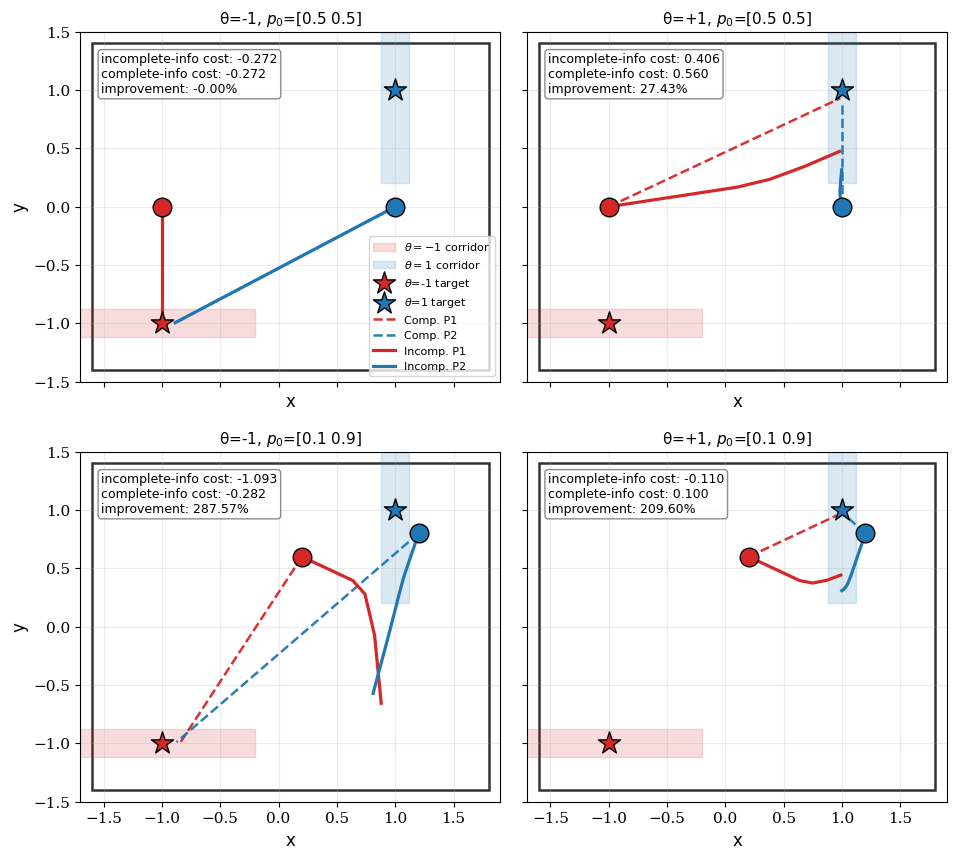

In [17]:
num_rows = len(scenarios)
num_cols = game.I
fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 5*num_rows), squeeze=False, sharex=True, sharey=True)

norm = plt.Normalize(vmin=0.0, vmax=1.0)
cmap = plt.cm.get_cmap("turbo")

for r, s in enumerate(scenarios):
    name = s["name"]
    prior_np = s["prior"].detach().cpu().numpy()
    res = scenario_results[name]

    root_inc = float(res["root_loss"])
    root_ci = sum(float(prior_np[i]) * float(res["complete_info"][i]["root_loss"]) for i in range(game.I))
    root_delta = root_inc - root_ci

    for c in range(num_cols):
        ax = axes[r, c]

        ro = res["rollouts"][c]["rollout"]
        policy_cost = res["rollouts"][c]["cost"]

        ro_ci = res["complete_info"][c]["rollout"]
        ci_cost = res["complete_info"][c]["cost"]

        plot_hexner_mod_context(ax=ax, game=game, legend=(r == 0 and c == 0))
        plot_hexner_mod_trajectory(
            ax=ax,
            game=game,
            rollout=ro_ci,
            label_prefix=f"Comp.",
            line_style="--",
            line_width=1.8,
            alpha=0.95,
            show_context=False,
            show_belief_markers=False,
            add_start_markers=False,
            legend=False,
        )
        plot_hexner_mod_trajectory(
            ax=ax,
            game=game,
            rollout=ro,
            label_prefix=f"Incomp.",
            line_style="-",
            line_width=2.3,
            alpha=1.0,
            show_context=False,
            show_belief_markers=False,
            belief_component=0,
            belief_label=r"$p(\theta_0)$",
            belief_cmap="turbo",
            belief_marker_size=65.0,
            belief_marker_alpha=0.95,
            belief_marker_perimeter_only=True,
            show_colorbar=False,
            add_start_markers=True,
            legend=(r == 0 and c == 0),
        )

        ax.text(
            0.05,
            0.94,
            f"incomplete-info cost: {policy_cost:.3f}\n"
            f"complete-info cost: {ci_cost:.3f}\n"
            # f"GT cost: {gt_cost:.3f}",
            f"improvement: {-100*(policy_cost - ci_cost)/abs(ci_cost):.2f}%",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9),
            zorder=10,
        )

        #-0.098088 0.002302            0.107933        0.061809   0.061810 
        # if r == 0 and c == 1:
        #     ax.text(
        #         -0.24,
        #         0.8,
        #         f"$\\mathbf{{E}}$[cost$_{{inc}}$]: {0.106914:.4f}\n"
        #         f"cost$_{{c}}$: {0.143968:.4f}\n"
        #         f"Δcost: {0.106914 - 0.143968:.4f}",
        #         transform=ax.transAxes,
        #         ha="left",
        #         va="bottom",
        #         fontsize=9,
        #         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.9),
        #         zorder=10,
        #     )
        # if r == 1 and c == 1:
        #     ax.text(
        #         -0.24,
        #         0.8,
        #         f"$\\mathbf{{E}}$[cost$_{{inc}}$]: {-0.098088:.4f}\n"
        #         f"cost$_{{c}}$: {0.061810:.4f}\n"
        #         f"Δcost: {-0.098088 - 0.061810:.4f}",
        #         transform=ax.transAxes,
        #         ha="left",
        #         va="bottom",
        #         fontsize=9,
        #         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.9),
        #         zorder=10,
        #     )

        ax.set_title(
            f"θ={float(game.theta_vals[c]):+.0f}, $p_0$={prior_np.round(2)}",
            fontsize=11,
        )

# sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.32, pad=0.02)
# cbar.set_label(r"$p(\theta_0)$")
plt.subplots_adjust(wspace=-0.3)
axes[0, 1].set_ylabel('')
axes[1, 1].set_ylabel('')

plt.savefig('drone_1.png', dpi=600)
plt.show()


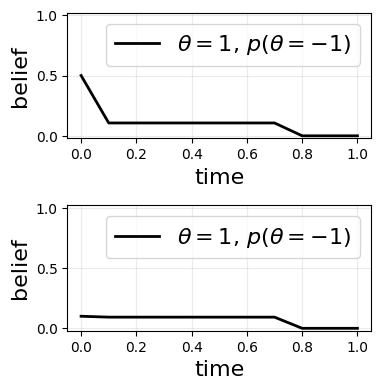

In [19]:
# fig, axes = plt.subplots(len(scenarios), 1, figsize=(11, 3.2 * len(scenarios)), squeeze=False)
fig, axes = plt.subplots(len(scenarios), 1, figsize=(4, 2 * len(scenarios)), squeeze=False)

for r, s in enumerate(scenarios):
    name = s["name"]
    ax = axes[r, 0]

    for type_idx, color in [(0, "black"), (1, "black")]:
        b_no = scenario_results[name]['rollouts'][type_idx]["rollout"].belief_traj.detach().cpu().numpy()
        # b_rs = scenario_results[name]['rollouts'][type_idx]["rollout"].belief_traj.detach().cpu().numpy()

        t_no = np.linspace(0.0, float(game_cfg.T), b_no.shape[0])
        # t_rs = np.linspace(0.0, float(game_cfg.T), b_rs.shape[0])

        if type_idx == 1:
            ax.plot(t_no, b_no[:, 0], "-", color=color, linewidth=2, label=f"$\\theta={2*type_idx-1}$, $p(\\theta=-1)$")
        # ax.plot(t_rs, b_rs[:, 0], "-", color=color, linewidth=2.2, alpha=0.95, label=f"type={type_idx} resolve")

    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel("belief", fontsize=16)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=16, ncol=2, loc="best")

plt.tight_layout()
plt.savefig('belief_case_2.png', dpi=600)
plt.show()


In [20]:
scenario_results[scenarios[0]['name']]['rollouts'][0]['rollout'].belief_traj

tensor([[5.0000e-01, 5.0000e-01],
        [9.9999e-01, 5.0749e-06],
        [1.0000e+00, 3.0687e-08],
        [1.0000e+00, 4.7152e-10],
        [1.0000e+00, 7.8972e-12],
        [1.0000e+00, 6.6609e-11],
        [1.0000e+00, 3.1448e-11],
        [1.0000e+00, 4.2767e-11],
        [1.0000e+00, 5.7271e-11],
        [1.0000e+00, 6.4068e-11],
        [1.0000e+00, 5.1919e-11]])

In [28]:
scenario_results[scenarios[0]['name']]['alpha'][0, 0, ...]

tensor([[1.1923e-01, 8.8077e-01],
        [1.0000e+00, 4.4698e-06]])

In [37]:
lam_edge = scenario_results[scenarios[0]['name']]['belief_tree'].lambda_edge[0][0]
kappa_u_all = scenario_results[scenarios[0]['name']]['riccati_sol'].kappa_u[0][0]
kappa_v_all = scenario_results[scenarios[0]['name']]['riccati_sol'].kappa_v[0][0]
kappa_u = torch.einsum("a,ad->d", lam_edge, kappa_u_all)
kappa_u, kappa_u_all

(tensor([ 0.4504, -0.7771]),
 tensor([[ 2.7592,  0.8514],
         [-2.4836, -2.8464]]))

In [69]:
# Large-rollout sanity check: prior-weighted rollout cost vs root value
# Goal: verify E_rollout is close to root objective for both incomplete and complete-info.

LARGE_ROLLOUT_TRIALS = 4000
LARGE_ROLLOUT_SAMPLE_ACTIONS = True
BASE_SEED_LARGE = 880000


def _mc_rollout_stats(*, alpha_eval, belief_tree_eval, riccati_eval, x0_eval, type_index, seed_offset):
    costs = np.empty(int(LARGE_ROLLOUT_TRIALS), dtype=np.float64)
    for trial in range(int(LARGE_ROLLOUT_TRIALS)):
        gen = None
        if LARGE_ROLLOUT_SAMPLE_ACTIONS:
            gen = torch.Generator(device=device)
            gen.manual_seed(int(BASE_SEED_LARGE + seed_offset + trial))

        ro = rollout_trajectory(
            game=game,
            indexer=indexer,
            belief_tree=belief_tree_eval,
            riccati_sol=riccati_eval,
            alpha=alpha_eval,
            x0=x0_eval,
            type_index=type_index,
            action_space=eval_action_space,
            sample_actions=LARGE_ROLLOUT_SAMPLE_ACTIONS,
            generator=gen,
        )
        costs[trial] = rollout_total_cost(game=game, rollout=ro, type_index=type_index)

    mean = float(costs.mean())
    std = float(costs.std(ddof=1)) if costs.size > 1 else 0.0
    se = float(std / np.sqrt(costs.size)) if costs.size > 1 else 0.0
    return mean, std, se


large_rows = []
for s in scenarios:
    name = s["name"]
    x0_s = s["x0"]
    p0_np = s["prior"].detach().cpu().numpy()
    res = scenario_results[name]

    # Root objectives (prior-weighted comparison target)
    J_inc_root = float(res["root_loss"])
    J_ci_root = sum(float(p0_np[i]) * float(res["complete_info"][i]["root_loss"]) for i in range(game.I))

    # Incomplete: large-rollout per type, then prior-weighted
    inc_means, inc_ses = [], []
    for type_idx in range(game.I):
        m, _std, se = _mc_rollout_stats(
            alpha_eval=res["alpha"],
            belief_tree_eval=res["belief_tree"],
            riccati_eval=res["riccati_sol"],
            x0_eval=x0_s,
            type_index=type_idx,
            seed_offset=10000 + 2000 * int(type_idx),
        )
        inc_means.append(m)
        inc_ses.append(se)

    E_roll_inc = float(sum(float(p0_np[i]) * inc_means[i] for i in range(game.I)))
    E_roll_inc_se = float(np.sqrt(sum((float(p0_np[i]) ** 2) * (inc_ses[i] ** 2) for i in range(game.I))))

    # Complete-info: one-hot prior by type, large-rollout per type, then prior-weighted
    ci_means, ci_ses = [], []
    for type_idx in range(game.I):
        prior_ci = torch.zeros_like(s["prior"])
        prior_ci[type_idx] = 1.0

        if USE_HANDCRAFTED_CI_ALPHA:
            alpha_ci = build_handcrafted_complete_info_alpha(action_index=0)
        else:
            with torch.no_grad():
                alpha_ci = model.single_alpha(x0=x0_s, p0=prior_ci)
                if PROJECT_ALPHA_ONEHOT:
                    alpha_ci = project_alpha_onehot(alpha_ci)

        _loss_ci, details_ci = primal_objective_from_alpha(
            game=game,
            alpha=alpha_ci,
            indexer=indexer,
            x0=x0_s,
            p0=prior_ci,
            action_space=eval_action_space,
            return_details=True,
        )

        m, _std, se = _mc_rollout_stats(
            alpha_eval=alpha_ci,
            belief_tree_eval=details_ci["belief_tree"],
            riccati_eval=details_ci["riccati_solution"],
            x0_eval=x0_s,
            type_index=type_idx,
            seed_offset=50000 + 2000 * int(type_idx),
        )
        ci_means.append(m)
        ci_ses.append(se)

    E_roll_ci = float(sum(float(p0_np[i]) * ci_means[i] for i in range(game.I)))
    E_roll_ci_se = float(np.sqrt(sum((float(p0_np[i]) ** 2) * (ci_ses[i] ** 2) for i in range(game.I))))

    large_rows.append(
        {
            "Scenario": name,
            "Prior": [round(float(v), 3) for v in p0_np.tolist()],
            "Trials/type": int(LARGE_ROLLOUT_TRIALS),
            "J_inc(root)": round(J_inc_root, 6),
            "E_roll_inc": round(E_roll_inc, 6),
            "SE_inc": round(E_roll_inc_se, 6),
            "|J_inc-E_roll_inc|": round(abs(J_inc_root - E_roll_inc), 6),
            "J_ci(root,exp)": round(J_ci_root, 6),
            "E_roll_ci": round(E_roll_ci, 6),
            "SE_ci": round(E_roll_ci_se, 6),
            "|J_ci-E_roll_ci|": round(abs(J_ci_root - E_roll_ci), 6),
            "Δ_root (inc-ci)": round(J_inc_root - J_ci_root, 6),
            "Δ_roll (inc-ci)": round(E_roll_inc - E_roll_ci, 6),
        }
    )

large_rollout_df = pd.DataFrame(large_rows)
print("Large-rollout consistency check (prior-weighted across types):")
print(large_rollout_df.to_string(index=False))


Large-rollout consistency check (prior-weighted across types):
                Scenario      Prior  Trials/type  J_inc(root)  E_roll_inc   SE_inc  |J_inc-E_roll_inc|  J_ci(root,exp)  E_roll_ci  SE_ci  |J_ci-E_roll_ci|  Δ_root (inc-ci)  Δ_roll (inc-ci)
      S0 balanced_center [0.5, 0.5]         4000     0.062026    0.108982 0.001630            0.046957        0.143968   0.143968    0.0               0.0        -0.081943        -0.034986
S3 common_type1_topright [0.1, 0.9]         4000    -0.206022   -0.095114 0.002517            0.110908        0.061809   0.061810    0.0               0.0        -0.267831        -0.156924


Rollout/objective consistency audit
  MATCH_ROOT_OBJECTIVE=True (action_space=None)
                Scenario      Prior  J_inc(root)  E_roll_inc  J_inc - E_roll_inc  J_ci(root, exp)  E_roll_ci  J_ci - E_roll_ci  Roll_inc - Roll_ci  Root_inc - Root_ci
      S0 balanced_center [0.5, 0.5]     0.062026    0.062028           -0.000002         0.143968   0.143968              -0.0           -0.081941           -0.081943
S3 common_type1_topright [0.1, 0.9]    -0.206022   -0.206022           -0.000000         0.061809   0.061810              -0.0           -0.267831           -0.267831
Conclusion check (expected rollout sign should match objective sign):
  S0 balanced_center: root Δ=-0.081943, rollout Δ=-0.081941 -> OK
  S3 common_type1_topright: root Δ=-0.267831, rollout Δ=-0.267831 -> OK


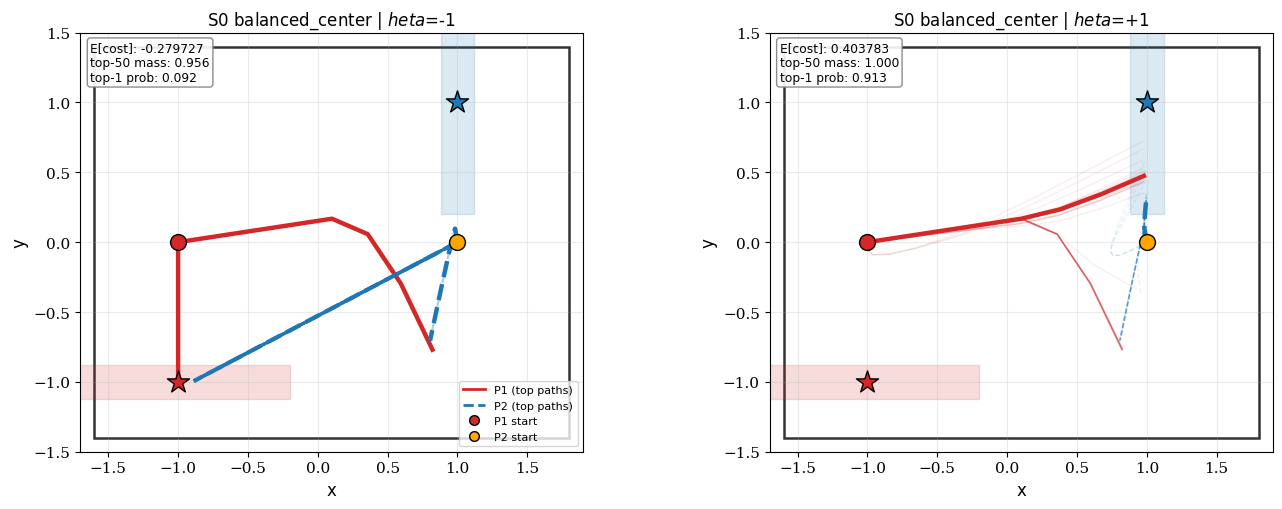

High-probability incomplete-info trajectory mass report:
          Scenario  Type      Prior  Expected rollout cost (incomplete)  Top-path mass  Top-1 path prob  Num nonzero paths
S0 balanced_center     0 [0.5, 0.5]                           -0.279727       0.955614         0.091670                827
S0 balanced_center     1 [0.5, 0.5]                            0.403783       0.999987         0.913232                651


In [24]:
# Exact expected rollout-cost audit (objective-consistent) + top-path visualization
#
# Purpose:
# 1) Compute expected rollout cost exactly (path enumeration) for incomplete and complete-info policies.
# 2) Compare those expected rollout costs against root objectives.
# 3) Plot top-probability incomplete-info trajectories with transparency proportional to path probability.

from types import SimpleNamespace
import itertools
from matplotlib.lines import Line2D

# -----------------------------
# User controls
# -----------------------------
TRAJ_SCENARIO = scenarios[0]["name"]
TOP_PATHS = 50
PATH_PROB_EPS = 1e-12
MAX_ENUM_PATHS = 4096  # exact enumeration when I^K <= this

# Critical toggle:
# True  -> no clipping during rollout cost audit, so expected rollout should match root objective.
# False -> uses eval_action_space clipping (useful for deployment realism, but won't match objective exactly).
MATCH_ROOT_OBJECTIVE = True


def _rollout_action_space_for_audit():
    return None if MATCH_ROOT_OBJECTIVE else eval_action_space


def _path_prob_for_type(alpha: torch.Tensor, type_index: int, proto_seq) -> float:
    node_idx = 0
    prob = 1.0
    for k, a in enumerate(proto_seq):
        prob *= float(alpha[k, node_idx, type_index, a].detach().cpu().item())
        node_idx = indexer.child_index(k, node_idx, int(a))
    return float(prob)


def _rollout_fixed_proto_seq(
    *,
    belief_tree,
    riccati_sol,
    x0: torch.Tensor,
    type_index: int,
    proto_seq,
    action_space=None,
):
    K = indexer.K
    dx = game.dx
    du = game.du
    dv = game.dv

    x = x0.to(device=device, dtype=game_cfg.dtype).clone()
    node_idx = 0

    x_traj = torch.empty(K + 1, dx, device=device, dtype=game_cfg.dtype)
    u_traj = torch.empty(K, du, device=device, dtype=game_cfg.dtype)
    v_traj = torch.empty(K, dv, device=device, dtype=game_cfg.dtype)
    b_traj = torch.empty(K + 1, game.I, device=device, dtype=game_cfg.dtype)

    x_traj[0] = x
    b_traj[0] = belief_tree.beliefs[0][node_idx]

    for k in range(K):
        a = int(proto_seq[k])

        K_u_edge = riccati_sol.K_u[k][node_idx, a]
        K_v_edge = riccati_sol.K_v[k][node_idx, a]

        kappa_u_edge = riccati_sol.kappa_u[k][node_idx, a]    # (du,)
        kappa_v_edge = riccati_sol.kappa_v[k][node_idx, a]    # (dv,)
        u = K_u_edge @ x + kappa_u_edge
        v = K_v_edge @ x + kappa_v_edge
        
        # Keep timing consistent with rollout_trajectory: aggregate feedforward terms with lambda_edge.
        # lam_edge = belief_tree.lambda_edge[k][node_idx]
        # kappa_u_all = riccati_sol.kappa_u[k][node_idx]
        # kappa_v_all = riccati_sol.kappa_v[k][node_idx]
        # kappa_u = torch.einsum("a,ad->d", lam_edge, kappa_u_all)
        # kappa_v = torch.einsum("a,ad->d", lam_edge, kappa_v_all)

        # u = K_u_edge @ x + kappa_u
        # v = K_v_edge @ x + kappa_v

        if action_space is not None:
            u = action_space.clip_u(u)
            v = action_space.clip_v(v)

        u_traj[k] = u
        v_traj[k] = v

        x = game.step_dynamics(x, u, v)
        x_traj[k + 1] = x

        child_idx = indexer.child_index(k, node_idx, a)
        b_traj[k + 1] = belief_tree.beliefs[k + 1][child_idx]
        node_idx = child_idx

    return {
        "x_traj": x_traj,
        "u_traj": u_traj,
        "v_traj": v_traj,
        "belief_traj": b_traj,
        "proto_seq": tuple(int(v) for v in proto_seq),
    }


def _enumerate_expected_cost_for_type(
    *,
    alpha,
    belief_tree,
    riccati_sol,
    x0,
    type_index,
    action_space,
):
    num_paths = game.I ** game_cfg.K
    if num_paths > MAX_ENUM_PATHS:
        raise RuntimeError(
            f"I^K={num_paths} exceeds MAX_ENUM_PATHS={MAX_ENUM_PATHS}. "
            f"Increase MAX_ENUM_PATHS or reduce horizon."
        )

    all_paths = []
    for seq in itertools.product(range(game.I), repeat=game_cfg.K):
        p_seq = _path_prob_for_type(alpha, type_index, seq)
        if p_seq <= PATH_PROB_EPS:
            continue

        ro = _rollout_fixed_proto_seq(
            belief_tree=belief_tree,
            riccati_sol=riccati_sol,
            x0=x0,
            type_index=type_index,
            proto_seq=seq,
            action_space=action_space,
        )
        c_seq = rollout_total_cost(
            game=game,
            rollout=SimpleNamespace(**ro),
            type_index=type_index,
        )

        all_paths.append(
            {
                "seq": seq,
                "prob": float(p_seq),
                "cost": float(c_seq),
                "x_traj": ro["x_traj"],
            }
        )

    if len(all_paths) == 0:
        raise RuntimeError(f"No nonzero-probability paths for type {type_index}")

    z = sum(v["prob"] for v in all_paths)
    for v in all_paths:
        v["prob"] /= z

    expected_cost = float(sum(v["prob"] * v["cost"] for v in all_paths))
    all_paths.sort(key=lambda d: d["prob"], reverse=True)
    return expected_cost, all_paths


# -----------------------------
# Global audit across all scenarios
# -----------------------------
action_space_audit = _rollout_action_space_for_audit()
audit_rows = []

for s in scenarios:
    name = s["name"]
    x0_s = s["x0"]
    p0_s = s["prior"].detach().cpu().numpy()
    res = scenario_results[name]

    # Incomplete policy components from scenario_results
    alpha_inc = res["alpha"]
    belief_inc = res["belief_tree"]
    riccati_inc = res["riccati_sol"]

    # Expected incomplete rollout cost, prior-weighted over true type
    inc_by_type = []
    for type_idx in range(game.I):
        c_inc, _ = _enumerate_expected_cost_for_type(
            alpha=alpha_inc,
            belief_tree=belief_inc,
            riccati_sol=riccati_inc,
            x0=x0_s,
            type_index=type_idx,
            action_space=action_space_audit,
        )
        inc_by_type.append(c_inc)
    inc_pw = float(sum(float(p0_s[i]) * inc_by_type[i] for i in range(game.I)))

    # Complete-info expected rollout cost with same CI policy construction as evaluate_scenario
    ci_by_type = []
    ci_root_pw = 0.0
    for type_idx in range(game.I):
        prior_ci = torch.zeros_like(s["prior"])
        prior_ci[type_idx] = 1.0

        if USE_HANDCRAFTED_CI_ALPHA:
            alpha_ci = build_handcrafted_complete_info_alpha(action_index=0)
        else:
            with torch.no_grad():
                alpha_ci = model.single_alpha(x0=x0_s, p0=prior_ci)
                if PROJECT_ALPHA_ONEHOT:
                    alpha_ci = project_alpha_onehot(alpha_ci)

        loss_ci, details_ci = primal_objective_from_alpha(
            game=game,
            alpha=alpha_ci,
            indexer=indexer,
            x0=x0_s,
            p0=prior_ci,
            action_space=eval_action_space,
            return_details=True,
        )

        c_ci, _ = _enumerate_expected_cost_for_type(
            alpha=alpha_ci,
            belief_tree=details_ci["belief_tree"],
            riccati_sol=details_ci["riccati_solution"],
            x0=x0_s,
            type_index=type_idx,
            action_space=action_space_audit,
        )

        ci_by_type.append(c_ci)
        ci_root_pw += float(p0_s[type_idx]) * float(loss_ci.detach().cpu().item())

    ci_pw = float(sum(float(p0_s[i]) * ci_by_type[i] for i in range(game.I)))

    J_inc_root = float(res["root_loss"])

    audit_rows.append(
        {
            "Scenario": name,
            "Prior": [round(float(x), 3) for x in p0_s.tolist()],
            "J_inc(root)": round(J_inc_root, 6),
            "E_roll_inc": round(inc_pw, 6),
            "J_inc - E_roll_inc": round(J_inc_root - inc_pw, 6),
            "J_ci(root, exp)": round(ci_root_pw, 6),
            "E_roll_ci": round(ci_pw, 6),
            "J_ci - E_roll_ci": round(ci_root_pw - ci_pw, 6),
            "Roll_inc - Roll_ci": round(inc_pw - ci_pw, 6),
            "Root_inc - Root_ci": round(J_inc_root - ci_root_pw, 6),
        }
    )

audit_df = pd.DataFrame(audit_rows)

print("Rollout/objective consistency audit")
print(f"  MATCH_ROOT_OBJECTIVE={MATCH_ROOT_OBJECTIVE} (action_space={'None' if action_space_audit is None else 'eval_action_space'})")
print(audit_df.to_string(index=False))

print("Conclusion check (expected rollout sign should match objective sign):")
for _, row in audit_df.iterrows():
    same_sign = np.sign(row["Roll_inc - Roll_ci"]) == np.sign(row["Root_inc - Root_ci"])
    verdict = "OK" if same_sign else "MISMATCH"
    print(
        f"  {row['Scenario']}: "
        f"root Δ={row['Root_inc - Root_ci']:+.6f}, rollout Δ={row['Roll_inc - Roll_ci']:+.6f} -> {verdict}"
    )


# -----------------------------
# Top-path plot for one scenario (incomplete-info)
# -----------------------------
res = scenario_results[TRAJ_SCENARIO]
alpha_inc = res["alpha"]
belief_inc = res["belief_tree"]
riccati_inc = res["riccati_sol"]

x0_s = None
prior_s = None
for s in scenarios:
    if s["name"] == TRAJ_SCENARIO:
        x0_s = s["x0"]
        prior_s = s["prior"]
        break
if x0_s is None:
    raise ValueError(f"Scenario '{TRAJ_SCENARIO}' not found")

report_rows = []
fig, axes = plt.subplots(1, game.I, figsize=(7.0 * game.I, 5.2), squeeze=False)

for type_idx in range(game.I):
    expected_cost, all_paths = _enumerate_expected_cost_for_type(
        alpha=alpha_inc,
        belief_tree=belief_inc,
        riccati_sol=riccati_inc,
        x0=x0_s,
        type_index=type_idx,
        action_space=action_space_audit,
    )

    top = all_paths[: int(TOP_PATHS)]
    top_mass = float(sum(v["prob"] for v in top))

    report_rows.append(
        {
            "Scenario": TRAJ_SCENARIO,
            "Type": int(type_idx),
            "Prior": [round(float(x), 3) for x in prior_s.detach().cpu().tolist()],
            "Expected rollout cost (incomplete)": round(expected_cost, 6),
            "Top-path mass": round(top_mass, 6),
            "Top-1 path prob": round(float(top[0]["prob"]), 6),
            "Num nonzero paths": int(len(all_paths)),
        }
    )

    ax = axes[0, type_idx]
    plot_hexner_mod_context(ax=ax, game=game, legend=False)

    pmax = float(top[0]["prob"])
    for item in top:
        x_np = item["x_traj"].detach().cpu().numpy()
        p1 = x_np[:, :2]
        p2 = x_np[:, game.cfg.dx1 : game.cfg.dx1 + 2]

        rel = float(item["prob"]) / max(pmax, 1e-12)
        a = 0.08 + 0.92 * rel
        lw = 1.0 + 2.2 * rel

        ax.plot(p1[:, 0], p1[:, 1], color="tab:red", alpha=a, linewidth=lw)
        ax.plot(p2[:, 0], p2[:, 1], color="tab:blue", alpha=a, linewidth=lw, linestyle="--")

    x0_np = x0_s.detach().cpu().numpy()
    ax.scatter(x0_np[0], x0_np[1], marker="o", s=130, color="tab:red", edgecolors="black", zorder=7)
    ax.scatter(x0_np[game.cfg.dx1], x0_np[game.cfg.dx1 + 1], marker="o", s=130, color="orange", edgecolors="black", zorder=7)

    theta_val = float(game.theta_vals[type_idx].detach().cpu().item())
    ax.set_title(f"{TRAJ_SCENARIO} | $\theta$={theta_val:+.0f}")

    ax.text(
        0.02,
        0.98,
        f"E[cost]: {expected_cost:.6f}\n"
        f"top-{len(top)} mass: {top_mass:.3f}\n"
        f"top-1 prob: {top[0]['prob']:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9),
    )

legend_items = [
    Line2D([0], [0], color="tab:red", linewidth=2.0, label="P1 (top paths)"),
    Line2D([0], [0], color="tab:blue", linestyle="--", linewidth=2.0, label="P2 (top paths)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:red", markeredgecolor="black", markersize=7, label="P1 start"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="orange", markeredgecolor="black", markersize=7, label="P2 start"),
]
axes[0, 0].legend(handles=legend_items, fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

traj_mass_df = pd.DataFrame(report_rows)
print("High-probability incomplete-info trajectory mass report:")
print(traj_mass_df.to_string(index=False))

